# 📋 Gabungan Notebook: Preprocessing + Data Prep Wildan
Notebook ini berisi **penggabungan mentah** dari dua notebook:
1. `youtube_analytics_preprocessing.ipynb` (preprocessing pipeline qiqi)
2. `data_prep_wildan.ipynb` (data prep & outlier analysis Wildan)

> **Silakan review, edit, dan hapus bagian yang tidak diperlukan.**


---
# 🔵 BAGIAN 1: youtube_analytics_preprocessing.ipynb
---

# 🎬 YouTube Analytics — Unified Preprocessing Pipeline
**Project:** Model Prediksi dan Diagnosa Penurunan Views YouTube  
**Pipeline:** Load Raw → Clean → Normalize → IQR Outlier Handling → Correlation Filter → Export  
**Kontributor:** Wildan (Data Prep & Outlier Analysis), Qiqi (EDA), Akmal (Raw Data), Tim

> Notebook ini menggabungkan best practice dari `youtube_analytics_preprocessing` dan `data_prep_wildan.ipynb`.

## 1. Setup & Import Library

In [55]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Dataset Mentah
Memuat langsung dari `data_raw_fix/Data_Merged_Fix.csv` (sumber tunggal kebenaran).  
Tidak perlu `make_raw_data.py` terpisah — semua dilakukan di notebook ini.

In [56]:
RAW_PATH = '../../data_raw_fix/Data_Merged_Fix.csv'
df = pd.read_csv(RAW_PATH)
print(f"Ukuran data awal: {df.shape}")
df.head(3)

Ukuran data awal: (1988, 63)


,Content,Video title,Duration,Average view duration,Average percentage viewed (%),Engaged views,Stayed to watch (%),Average views per viewer,Unique viewers,New viewers,Returning viewers,Casual viewers,Regular viewers,Transaction revenue (IDR),Transactions,Revenue per transaction (IDR),YouTube Premium (IDR),Watch Page ads (IDR),Estimated DoubleClick revenue (IDR),Estimated AdSense revenue (IDR),YouTube ad revenue (IDR),Ad impressions,Playback-based CPM (IDR),CPM (IDR),Estimated monetized playbacks,RPM (IDR),Rubies,YouTube Premium views,YouTube Premium watch time (hours),Playlist watch time (hours),Views from playlist,Views per playlist start,Hours streamed,Reminders set,Chat messages,Reactions,Post subscribers,Remix count,Remix views,Community clip views,Watch time from community clips (hours),Card clicks,Cards shown,Clicks per card shown (%),Card teaser clicks,Card teasers shown,Teaser clicks per card teaser shown (%),End screen element clicks,End screen elements shown,Clicks per end screen element shown (%),Views,Watch time (hours),Subscribers,Estimated revenue (IDR),Impressions,Impressions click-through rate (%),Video_ID,TS1_Views,TS2_Views,TS3_Views,TS4_Views,Publish_Date_WIB,Publish_Time_WIB
0,L7ZI56pInIg,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,0:05:08,51.37,7225.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7225.0,618.6350,1.0,NaN,26219.0,24.58,L7ZI56pInIg,0.0,0.0,0.0,0.0,2026-05-08,19:15:06
1,7UmhyS2pDQA,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,0:04:41,46.85,9831.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,196.718,9588.286,0.0,9588.286,17445.450,2160.0,9872.920,8076.597,1767.0,NaN,0.0,19.0,1.5073,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,35.0,1343.0,2.61,9831.0,767.6618,1.0,9785.004,32708.0,26.14,7UmhyS2pDQA,0.0,0.0,NaN,0.0,2026-05-08,11:15:06
2,jWmDRjojWLk,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,0:04:00,40.15,4177.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,285.101,19902.939,0.0,19902.939,36210.022,3854.0,11169.038,9395.439,3242.0,5538.515,0.0,40.0,1.9460,NaN,NaN,NaN,0.1998,19.0,2.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,49.0,2321.0,2.11,4177.0,279.5067,-2.0,20188.040,16230.0,19.19,jWmDRjojWLk,0.0,0.0,0.0,0.0,2026-05-07,07:15:06


## 3. Standardisasi Nama Kolom (dari Wildan)
Mengubah semua kolom menjadi *snake_case* (huruf kecil semua, spasi diganti underscore, membuang karakter khusus seperti `(%)`, `(IDR)`, dll).

In [57]:
def clean_col_name(col: str) -> str:
    col = col.strip().lower()
    col = col.replace(' (%)', '_pct')
    col = col.replace(' (idr)', '_idr')
    col = col.replace(' (hours)', '_hours')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    return col.strip('_')

df.columns = [clean_col_name(c) for c in df.columns]
print("Kolom setelah distandarisasi:")
for i, c in enumerate(df.columns):
    print(f"  {i:2d}. {c} (dtype={df[c].dtype}, nulls={df[c].isnull().sum()})")

Kolom setelah distandarisasi:
   0. content (dtype=str, nulls=0)
   1. video_title (dtype=str, nulls=0)
   2. duration (dtype=float64, nulls=0)
   3. average_view_duration (dtype=str, nulls=0)
   4. average_percentage_viewed_pct (dtype=float64, nulls=0)
   5. engaged_views (dtype=float64, nulls=0)
   6. stayed_to_watch_pct (dtype=float64, nulls=1864)
   7. average_views_per_viewer (dtype=float64, nulls=1667)
   8. unique_viewers (dtype=float64, nulls=1667)
   9. new_viewers (dtype=float64, nulls=1667)
  10. returning_viewers (dtype=float64, nulls=1667)
  11. casual_viewers (dtype=float64, nulls=1667)
  12. regular_viewers (dtype=float64, nulls=1667)
  13. transaction_revenue_idr (dtype=float64, nulls=1)
  14. transactions (dtype=float64, nulls=1)
  15. revenue_per_transaction_idr (dtype=float64, nulls=1757)
  16. youtube_premium_idr (dtype=float64, nulls=1)
  17. watch_page_ads_idr (dtype=float64, nulls=1)
  18. estimated_doubleclick_revenue_idr (dtype=float64, nulls=1)
  19. estimated

## 4. Penyesuaian Tipe Data (dari Wildan)
- Mengubah `average_view_duration` (String "HH:MM:SS") menjadi numerik (Total Detik)
- Memastikan `publish_date_wib` menjadi datetime
- Mengekstrak `publish_hour` dari `publish_time_wib`

In [58]:
!pip install emoji

In [59]:
import emoji

# Fungsi untuk menghapus emoji
def hapus_emoji(teks):
    if pd.isna(teks): # Cek jika ada nilai kosong (NaN)
        return teks
    # replace_emoji akan mengubah semua emoji menjadi string kosong
    return emoji.replace_emoji(str(teks), replace='')

# Terapkan fungsi ke kolom judul video
df['video_title'] = df['video_title'].apply(hapus_emoji)

# Hapus spasi berlebih yang mungkin tersisa setelah emoji dihapus
df['video_title'] = df['video_title'].str.strip()
df['video_title'] = df['video_title'].str.replace(r'\s+', ' ', regex=True)

print(" Emoji pada video_title berhasil dibersihkan!")

 Emoji pada video_title berhasil dibersihkan!


In [60]:
def time_to_seconds(time_str) -> float:
    if pd.isna(time_str):
        return np.nan
    try:
        parts = str(time_str).split(':')
        parts = [int(p) for p in parts]
        if len(parts) == 3:
            return parts[0] * 3600 + parts[1] * 60 + parts[2]
        elif len(parts) == 2:
            return parts[0] * 60 + parts[1]
        return float(parts[0])
    except:
        return np.nan

if 'average_view_duration' in df.columns:
    df['avg_view_duration_sec'] = df['average_view_duration'].apply(time_to_seconds)
    df = df.drop(columns=['average_view_duration'])
    print("✅ average_view_duration → avg_view_duration_sec (detik)")

if 'publish_date_wib' in df.columns:
    df['publish_date'] = pd.to_datetime(df['publish_date_wib'], errors='coerce')
    df = df.drop(columns=['publish_date_wib'])
    print("✅ publish_date_wib → publish_date (datetime)")

if 'publish_time_wib' in df.columns:
    df['publish_hour'] = pd.to_datetime(df['publish_time_wib'], format='%H:%M:%S', errors='coerce').dt.hour
    
    print("✅ publish_time_wib → publish_hour (int)")

# Pastikan semua kolom numerik yang seharusnya numerik
non_numeric = ['video_id', 'video_title', 'publish_date']
for col in df.columns:
    if col not in non_numeric and df[col].dtype == 'object':
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"\nShape: {df.shape}")
df.dtypes

✅ average_view_duration → avg_view_duration_sec (detik)
✅ publish_date_wib → publish_date (datetime)
✅ publish_time_wib → publish_hour (int)

Shape: (1988, 64)


content                                     str
video_title                                 str
duration                                float64
average_percentage_viewed_pct           float64
engaged_views                           float64
                                      ...      
ts4_views                               float64
publish_time_wib                            str
avg_view_duration_sec                     int64
publish_date                     datetime64[us]
publish_hour                              int32
Length: 64, dtype: object

## 5. Penanganan Missing Values dan Redundansi (dari Wildan)

### 🧹 Logika Bisnis (Bukan Imputasi Buta)
1. **Drop Kolom Redundan:** Kolom yang tidak relevan untuk prediksi views
2. **Drop Kolom >95% Null:** Kolom yang terlalu kosong
3. **Imputasi TS1-TS4:** Fill 0 (belum ada data periode itu)
4. **Imputasi Revenue:** Fill 0 (video belum monetisasi)
5. **Imputasi Engagement:** Fill median (robust terhadap outlier)

In [61]:
# --- 5a. Drop kolom redundan (logika bisnis dari Wildan) ---
if 'content' in df.columns:
    df = df.drop(columns=['content'])

cols_to_drop_manual = [
    'stayed_to_watch_pct', 'average_views_per_viewer',
    'unique_viewers', 'new_viewers', 'returning_viewers',
    'casual_viewers', 'regular_viewers',
    'transaction_revenue_idr', 'transactions', 'revenue_per_transaction_idr',
    'playlist_watch_time_hours', 'views_from_playlist', 'views_per_playlist_start',
    'reminders_set', 'post_subscribers',
    'community_clip_views', 'watch_time_from_community_clips_hours',
    'card_clicks', 'cards_shown', 'clicks_per_card_shown_pct',
    'card_teaser_clicks', 'card_teasers_shown', 'teaser_clicks_per_card_teaser_shown_pct',
    'end_screen_element_clicks', 'end_screen_elements_shown', 'clicks_per_end_screen_element_shown_pct',
    'youtube_premium_views', 'youtube_premium_watch_time_hours',
    'rubies',
]
df = df.drop(columns=[c for c in cols_to_drop_manual if c in df.columns])
print(f"Setelah drop manual: {df.shape}")

# --- 5b. Drop kolom >95% null ---
threshold_95 = 0.95 * len(df)
df = df.dropna(axis=1, thresh=len(df) - threshold_95)
print(f"Setelah drop >95% null: {df.shape}")

# --- 5c. Imputasi Time Series ---
ts_cols = ['ts1_views', 'ts2_views', 'ts3_views', 'ts4_views']
for col in ts_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# --- 5d. Imputasi revenue → 0 ---
for col in df.columns:
    if any(p in col for p in ['revenue', 'ad_', 'cpm', 'rpm', 'yt_ad', 'estimated_monetized', 'playback_based']):
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(0)
            print(f"  fill 0: {col}")

# --- 5e. Imputasi engagement → median ---
numeric_cols = df.select_dtypes(include=['number']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f"  fill median ({med:.2f}): {col}")

print(f"\nTotal null tersisa: {df.isnull().sum().sum()}")
print(f"Shape: {df.shape}")

Setelah drop manual: (1988, 34)
Setelah drop >95% null: (1988, 32)
  fill 0: estimated_doubleclick_revenue_idr
  fill 0: estimated_adsense_revenue_idr
  fill 0: youtube_ad_revenue_idr
  fill 0: ad_impressions
  fill 0: playback_based_cpm_idr
  fill 0: cpm_idr
  fill 0: estimated_monetized_playbacks
  fill 0: rpm_idr
  fill 0: estimated_revenue_idr
  fill median (616.64): youtube_premium_idr
  fill median (41535.56): watch_page_ads_idr
  fill median (0.20): hours_streamed
  fill median (0.00): chat_messages
  fill median (0.00): reactions

Total null tersisa: 0
Shape: (1988, 32)


In [62]:
# Cek data setelah cleaning
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 32 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   video_title                         1988 non-null   str           
 1   duration                            1988 non-null   float64       
 2   average_percentage_viewed_pct       1988 non-null   float64       
 3   engaged_views                       1988 non-null   float64       
 4   youtube_premium_idr                 1988 non-null   float64       
 5   watch_page_ads_idr                  1988 non-null   float64       
 6   estimated_doubleclick_revenue_idr   1988 non-null   float64       
 7   estimated_adsense_revenue_idr       1988 non-null   float64       
 8   youtube_ad_revenue_idr              1988 non-null   float64       
 9   ad_impressions                      1988 non-null   float64       
 10  playback_based_cpm_idr             

,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_doubleclick_revenue_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,cpm_idr,estimated_monetized_playbacks,rpm_idr,hours_streamed,chat_messages,reactions,views,watch_time_hours,subscribers,estimated_revenue_idr,impressions,impressions_click_through_rate_pct,ts1_views,ts2_views,ts3_views,ts4_views,avg_view_duration_sec,publish_date,publish_hour
count,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1988.0,1.988000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1988.000000,1988,1988.000000
mean,585.245473,38.922485,25853.628270,1711.279911,7.905777e+04,0.0,7.903687e+04,1.437362e+05,18611.053320,8518.937781,7418.661707,16291.168008,3358.782134,0.202428,0.400905,1.138330,26326.197183,1606.907998,40.662475,8.179940e+04,1.669843e+05,13.666273,23575.512575,29332.710765,34871.606137,4.154714e+04,211.903421,2025-08-17 03:13:24.024144,13.779175
min,14.000000,10.020000,296.000000,0.000000,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,296.000000,10.166800,-5.000000,0.000000e+00,2.089000e+03,2.430000,0.000000,0.000000,0.000000,0.000000e+00,25.000000,2024-11-24 00:00:00,2.000000
25%,534.000000,33.440000,6700.250000,271.210250,2.094346e+04,0.0,2.085719e+04,3.809710e+04,4836.500000,7483.972250,6748.712250,4217.750000,2474.519000,0.189800,0.000000,0.000000,6981.500000,370.820500,3.000000,2.140121e+04,3.601000e+04,10.990000,4329.750000,5601.250000,6433.500000,6.854500e+03,191.000000,2025-04-26 00:00:00,10.000000
50%,581.000000,37.645000,12492.000000,616.644000,4.153556e+04,0.0,4.152483e+04,7.553468e+04,9355.500000,8725.785000,7620.631000,8045.500000,3178.528000,0.199800,0.000000,0.000000,12900.000000,733.799050,11.000000,4.222797e+04,7.501250e+04,12.880000,9204.000000,11635.500000,13842.000000,1.522450e+04,216.000000,2025-08-09 00:00:00,15.000000
75%,630.000000,41.480000,26413.250000,1650.703750,8.853701e+04,0.0,8.853701e+04,1.605033e+05,20109.250000,9960.822000,8522.915250,17745.250000,4099.055000,0.205425,0.000000,0.000000,27201.250000,1668.287325,34.000000,9.131860e+04,1.736500e+05,15.420000,23544.500000,28817.750000,33652.000000,3.869150e+04,240.000000,2025-12-17 00:00:00,18.000000
max,3485.000000,181.330000,827102.000000,86603.114000,2.952136e+06,0.0,2.952136e+06,5.367519e+06,636638.000000,50407.992000,40208.422000,564574.000000,30289.955000,0.416900,17.000000,337.000000,827102.000000,57962.028000,2123.000000,3.061625e+06,6.643679e+06,31.300000,386070.000000,640783.000000,907195.000000,1.174132e+06,716.000000,2026-05-08 00:00:00,23.000000
std,202.118444,11.467581,43628.142435,3956.571155,1.359138e+05,0.0,1.359227e+05,2.471212e+05,31347.265387,3034.698854,2498.851396,27714.379647,1628.845082,0.031167,1.130062,10.619203,43817.447456,2882.231531,112.333363,1.413182e+05,3.059040e+05,4.148299,41028.548336,52728.853701,64352.472436,8.161333e+04,50.906802,NaN,4.346704


## 6. Penanganan Duplikat Data

In [63]:
dupes = df.duplicated(subset=['video_id']).sum()
print(f"Duplikat berdasarkan video_id: {dupes}")
if dupes > 0:
    df = df.drop_duplicates(subset=['video_id'], keep='first')
    print(f"Shape setelah deduplikasi: {df.shape}")
else:
    print("Tidak ada duplikat.")

Duplikat berdasarkan video_id: 0
Tidak ada duplikat.


## 7. Analisis Outlier — Identifikasi Video Viral (dari Wildan)

### 📊 Boxplot Analisis
Boxplot di bawah ini digunakan untuk melihat sebaran data. Titik di luar batas atas adalah *outlier*.

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses dari memori model Machine Learning.

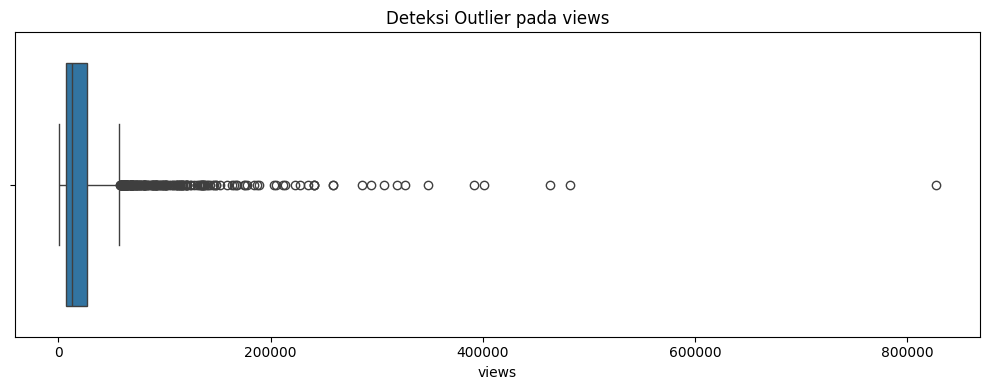

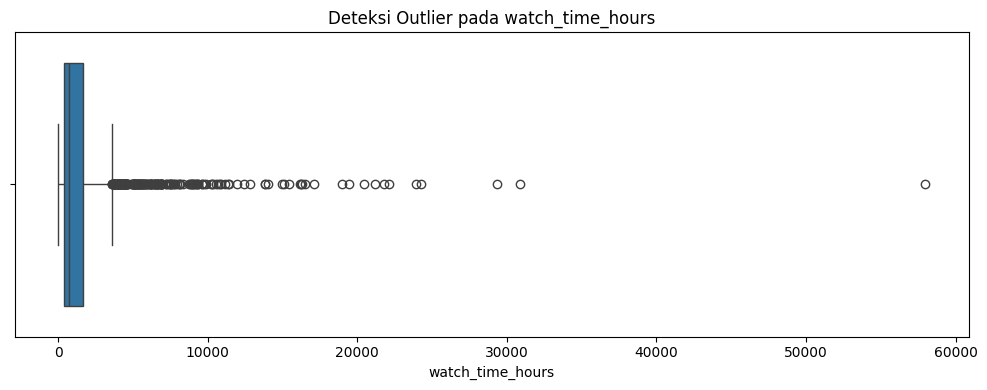

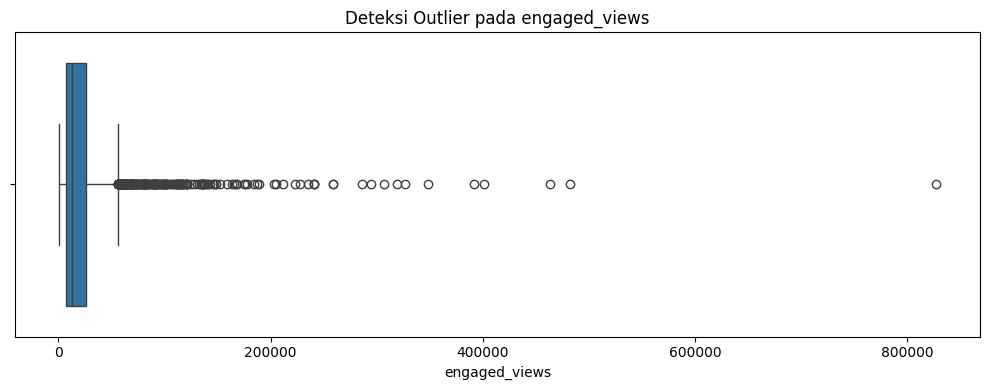

In [64]:
# --- 7a. Boxplot Metrik Performa ---
features_performance = ['views', 'watch_time_hours', 'engaged_views']
features_performance = [f for f in features_performance if f in df.columns]

for feature in features_performance:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

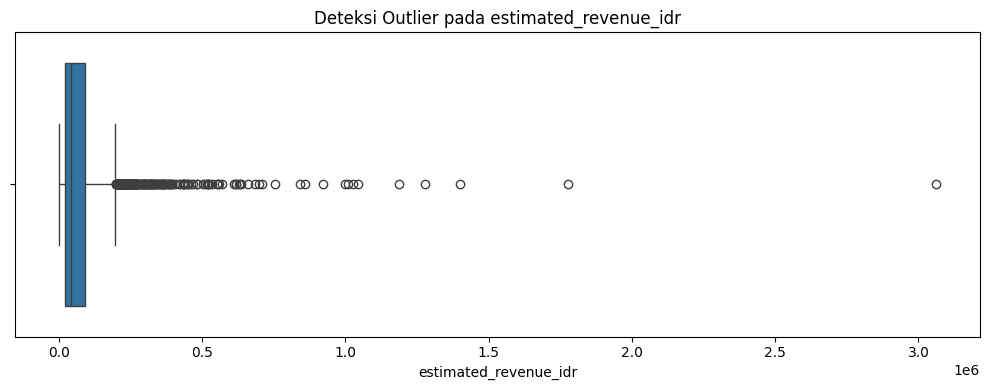

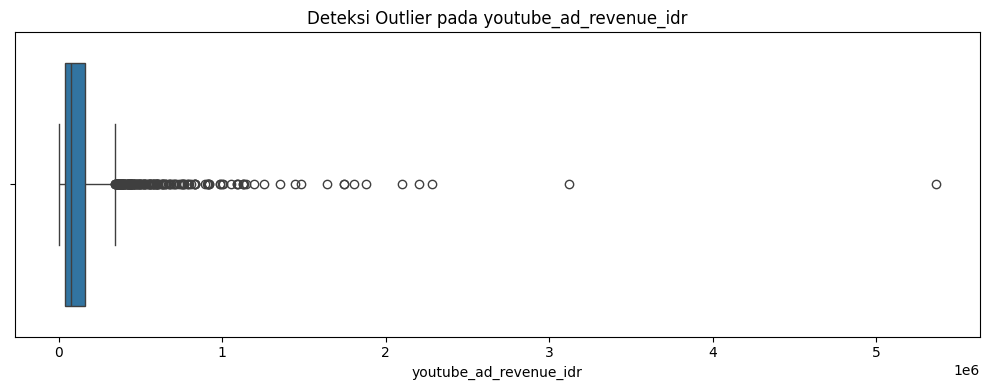

In [65]:
# --- 7b. Boxplot Metrik Revenue ---
features_revenue = ['estimated_revenue_idr', 'youtube_ad_revenue_idr']
features_revenue = [f for f in features_revenue if f in df.columns]

for feature in features_revenue:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

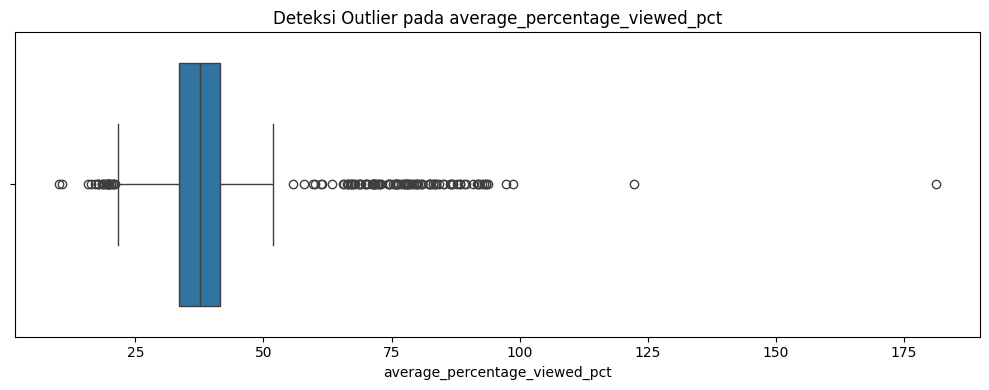

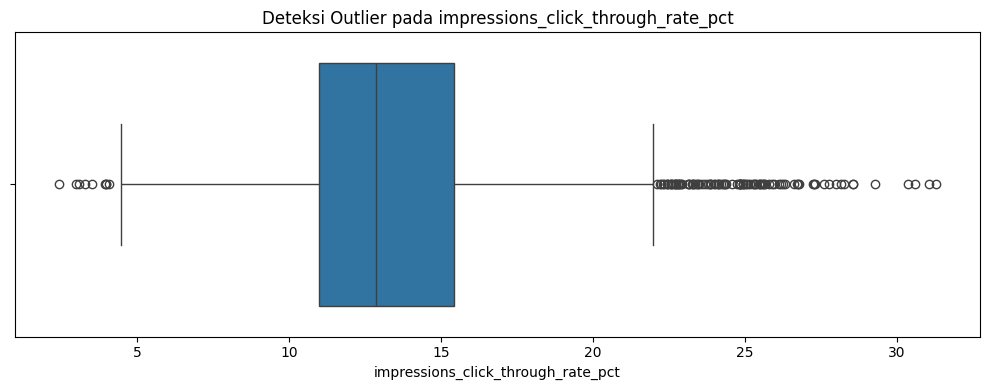

In [66]:
# --- 7c. Boxplot Retensi & Efisiensi ---
features_retention = ['average_percentage_viewed_pct', 'impressions_click_through_rate_pct']
features_retention = [f for f in features_retention if f in df.columns]

for feature in features_retention:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

## 8. IQR Flagging & Log Transform (dari Wildan)

### 🚀 IQR Flagging
Karena kita tidak menghapus video viral, kita memberi 'tanda' agar algoritma Machine Learning tahu bahwa video ini spesial.  
Kita menggunakan batas statistik matematis **Interquartile Range (IQR)**. Jika *views* sebuah video melewati batas atas, maka video tersebut diberi bendera `is_viral`.

In [67]:
# --- 8a. IQR Viral Flagging pada views ---
kolom_target = 'views'
Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
IQR = Q3 - Q1
batas_atas = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.0f}, Q3: {Q3:.0f}, IQR: {IQR:.0f}")
print(f"Batas atas (Viral Threshold): {batas_atas:.0f}")

df['is_viral'] = np.where(df[kolom_target] > batas_atas, 1, 0)
print(f"\nSebaran video viral vs normal:")
print(df['is_viral'].value_counts())
print(f"Video viral: {df['is_viral'].sum()} / {len(df)} ({df['is_viral'].mean()*100:.1f}%)")

Q1: 6982, Q3: 27201, IQR: 20220
Batas atas (Viral Threshold): 57531

Sebaran video viral vs normal:
is_viral
0    1785
1     203
Name: count, dtype: int64
Video viral: 203 / 1988 (10.2%)


### 📉 Normalisasi Data: Log Transformation (`np.log1p`)
Video viral memiliki rentang angka yang sangat jauh (jutaan) dibandingkan video normal (ribuan). Hal ini membuat algoritma (seperti Regresi) menjadi bias.  
Untuk menjinakkannya, kita menerapkan **Logaritma Natural (Log1p)**. Logika ini akan merapatkan skala angka ekstrem menjadi skala belasan, sehingga model bisa mempelajarinya dengan stabil tanpa kehilangan informasi esensial.

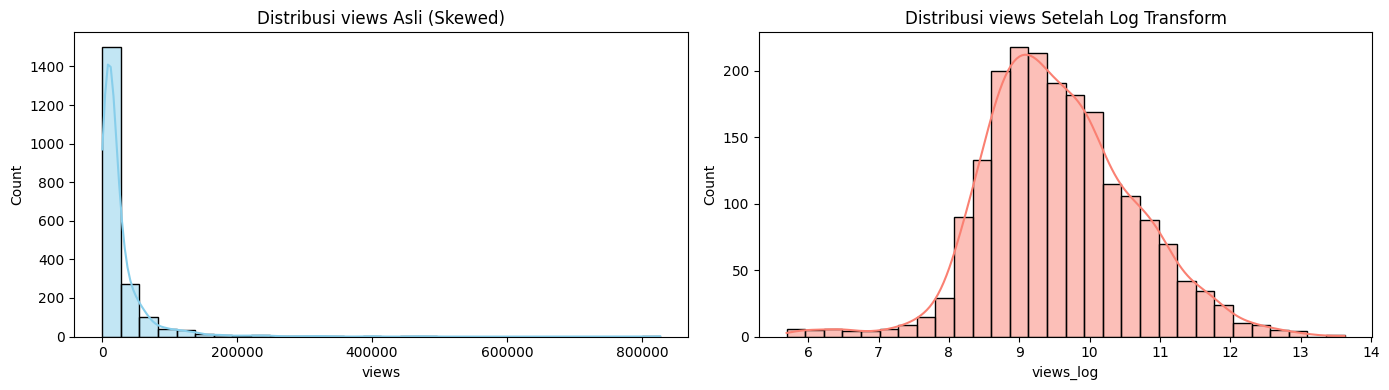

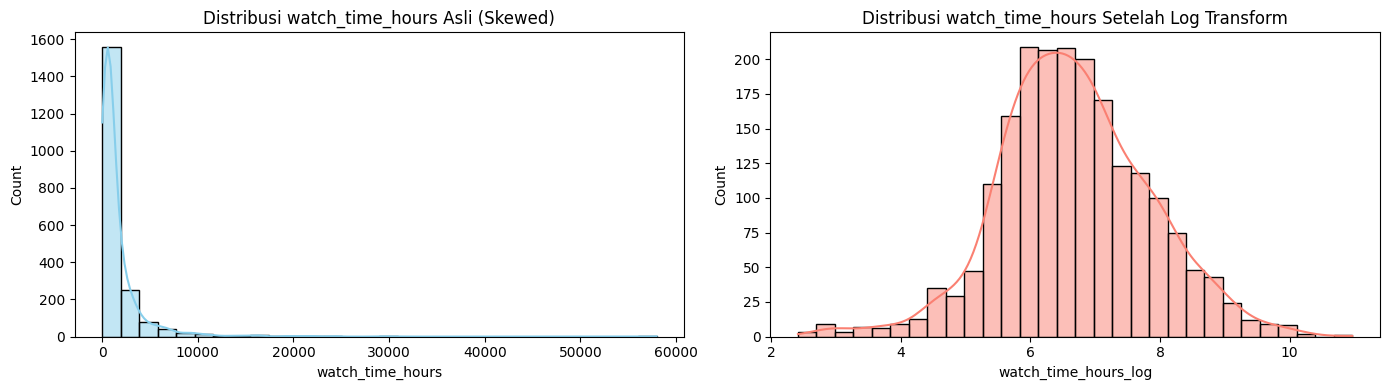

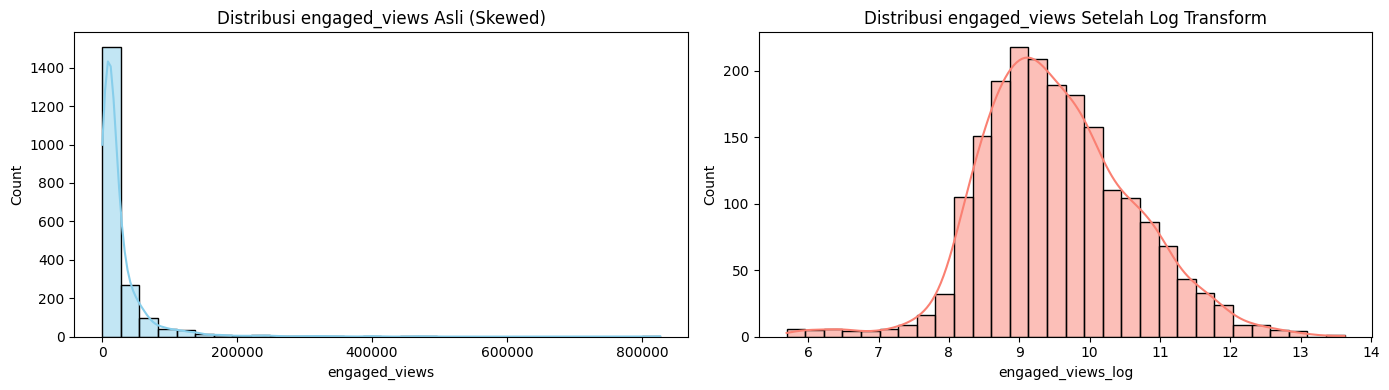


Statistik fitur log:
         views_log  watch_time_hours_log  engaged_views_log  impressions_log  \
count  1988.000000           1988.000000        1988.000000      1988.000000   
mean      9.568797              6.673678           9.539305        11.300517   
std       1.058019              1.169527           1.064818         1.174432   
min       5.693732              2.412945           5.693732         7.644919   
25%       8.851162              5.918411           8.810049        10.491580   
50%       9.465060              6.599597           9.432924        11.225422   
75%      10.211055              7.420152          10.181659        12.064803   
max      13.625685             10.967561          13.625685        15.709177   

       estimated_revenue_idr_log  ad_impressions_log  
count                1988.000000         1988.000000  
mean                   10.590850            8.758652  
std                     1.305835            2.399096  
min                     0.000000     

In [68]:
# --- 8b. Log Transformation dengan visualisasi before/after ---
outlier_features = ['views', 'watch_time_hours', 'engaged_views', 'impressions',
                    'estimated_revenue_idr', 'ad_impressions']
outlier_features = [f for f in outlier_features if f in df.columns]

for feature in outlier_features:
    df[f'{feature}_log'] = np.log1p(df[feature])

# Visualisasi before/after untuk views dan watch_time_hours
viz_features = [f for f in ['views', 'watch_time_hours', 'engaged_views'] if f in df.columns]
for feature in viz_features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    sns.histplot(df[feature], bins=30, ax=axes[0], kde=True, color='skyblue')
    axes[0].set_title(f'Distribusi {feature} Asli (Skewed)')
    
    sns.histplot(df[f'{feature}_log'], bins=30, ax=axes[1], kde=True, color='salmon')
    axes[1].set_title(f'Distribusi {feature} Setelah Log Transform')
    
    plt.tight_layout()
    plt.show()

print("\nStatistik fitur log:")
print(df[[f'{f}_log' for f in outlier_features]].describe())

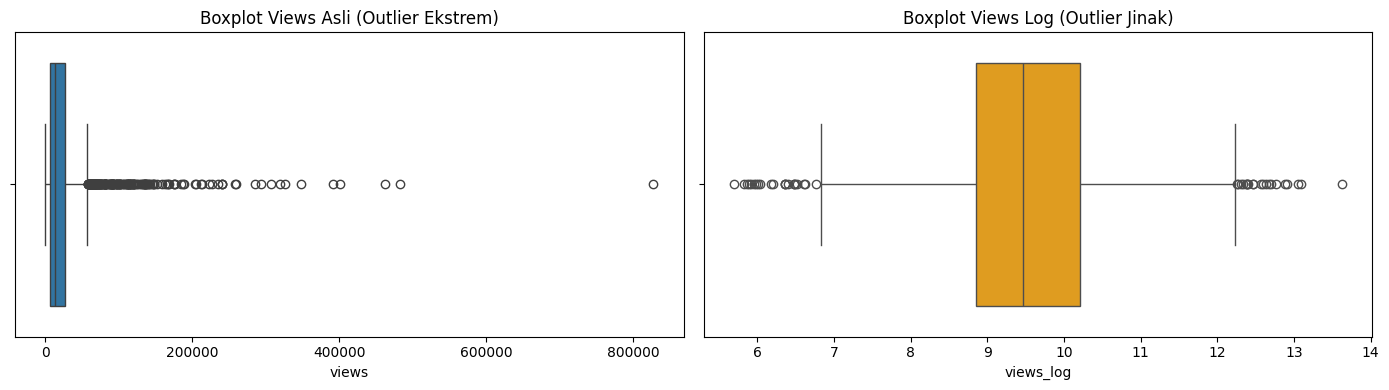

In [69]:
# --- 8c. Boxplot before/after views ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df['views'], ax=axes[0])
axes[0].set_title('Boxplot Views Asli (Outlier Ekstrem)')
sns.boxplot(x=df['views_log'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot Views Log (Outlier Jinak)')
plt.tight_layout()
plt.show()

## 9. Analisis Korelasi & Seleksi Fitur
**Target:** `views`  
**Aturan:**
1. Hapus fitur dengan korelasi < 0.05 terhadap target
2. Hapus satu dari pasangan fitur yang berkorelasi > 0.90 (multicollinearity)

In [70]:
# --- 9a. Korelasi terhadap target ---
target = 'views'
num_df = df.select_dtypes(include=[np.number])
corr_target = num_df.corr()[target].drop(target).abs().sort_values(ascending=False)

print("Korelasi terhadap 'views':")
print(corr_target.to_string())

LOW_CORR_THRESHOLD = 0.05
low_corr_features = corr_target[corr_target < LOW_CORR_THRESHOLD].index.tolist()
print(f"\nFitur korelasi rendah (<{LOW_CORR_THRESHOLD}): {low_corr_features}")

Korelasi terhadap 'views':
engaged_views                         0.997572
impressions                           0.977378
watch_time_hours                      0.975534
estimated_monetized_playbacks         0.960831
ad_impressions                        0.958388
estimated_revenue_idr                 0.945521
youtube_ad_revenue_idr                0.945086
estimated_adsense_revenue_idr         0.945066
watch_page_ads_idr                    0.945061
subscribers                           0.912885
youtube_premium_idr                   0.826104
views_log                             0.721284
engaged_views_log                     0.720397
is_viral                              0.712218
watch_time_hours_log                  0.678847
impressions_log                       0.678395
estimated_revenue_idr_log             0.574517
ts1_views                             0.506347
ts2_views                             0.482631
ts3_views                             0.462215
ts4_views                        

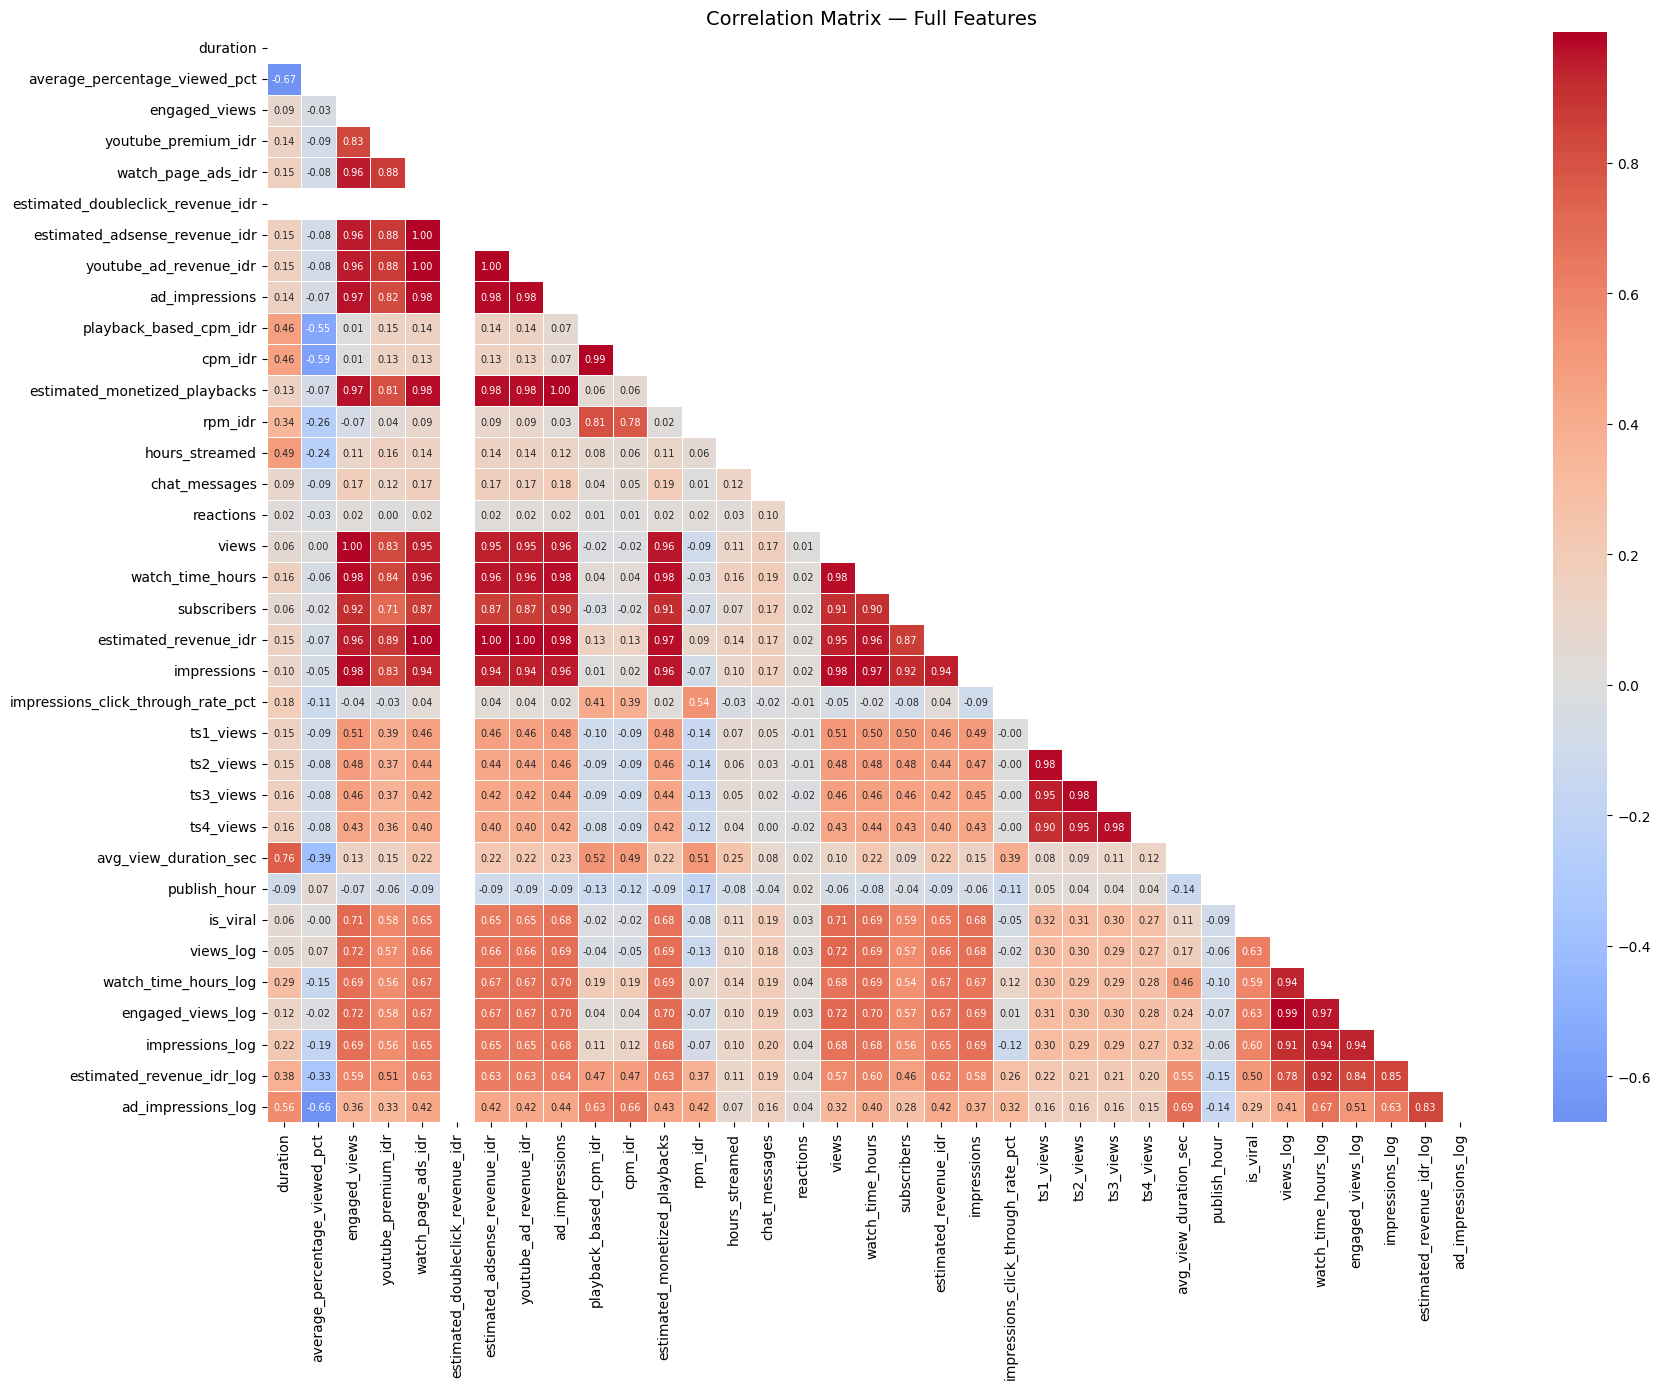

In [71]:
# --- 9b. Heatmap korelasi ---
fig, ax = plt.subplots(figsize=(18, 14))
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Correlation Matrix — Full Features', fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
# --- 9c. Deteksi multikolinearitas (>0.90) ---
MULTI_THRESHOLD = 0.90
pairs_to_check = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col_i, col_j = corr_matrix.columns[i], corr_matrix.columns[j]
        val = abs(corr_matrix.iloc[i, j])
        if val > MULTI_THRESHOLD:
            pairs_to_check.append((col_i, col_j, val))

print(f"Pasangan fitur multikolinear (>{MULTI_THRESHOLD}):")
for a, b, v in sorted(pairs_to_check, key=lambda x: -x[2]):
    print(f"  {a} ↔ {b}: {v:.3f}")

Pasangan fitur multikolinear (>0.9):
  estimated_adsense_revenue_idr ↔ youtube_ad_revenue_idr: 1.000
  watch_page_ads_idr ↔ estimated_adsense_revenue_idr: 1.000
  watch_page_ads_idr ↔ youtube_ad_revenue_idr: 1.000
  estimated_adsense_revenue_idr ↔ estimated_revenue_idr: 0.999
  youtube_ad_revenue_idr ↔ estimated_revenue_idr: 0.999
  watch_page_ads_idr ↔ estimated_revenue_idr: 0.999
  ad_impressions ↔ estimated_monetized_playbacks: 0.999
  engaged_views ↔ views: 0.998
  views_log ↔ engaged_views_log: 0.993
  playback_based_cpm_idr ↔ cpm_idr: 0.991
  ts2_views ↔ ts3_views: 0.984
  youtube_ad_revenue_idr ↔ ad_impressions: 0.984
  estimated_adsense_revenue_idr ↔ ad_impressions: 0.984
  watch_page_ads_idr ↔ ad_impressions: 0.984
  engaged_views ↔ watch_time_hours: 0.983
  engaged_views ↔ impressions: 0.983
  ts1_views ↔ ts2_views: 0.982
  ad_impressions ↔ estimated_revenue_idr: 0.981
  ad_impressions ↔ watch_time_hours: 0.980
  estimated_monetized_playbacks ↔ watch_time_hours: 0.980
  youtu

In [73]:
# --- 9d. Drop fitur bermasalah ---
cols_drop = set(low_corr_features)

for a, b, v in pairs_to_check:
    corr_a = abs(corr_target.get(a, 0))
    corr_b = abs(corr_target.get(b, 0))
    drop_col = b if corr_a >= corr_b else a
    cols_drop.add(drop_col)

cols_drop -= {target, 'is_viral', 'views_log'}
cols_drop = [c for c in cols_drop if c in df.columns]

print(f"Kolom yang di-drop ({len(cols_drop)}):")
for c in sorted(cols_drop):
    print(f"  - {c}")

df_clean = df.drop(columns=cols_drop)
print(f"\nShape akhir: {df_clean.shape}")

Kolom yang di-drop (21):
  - ad_impressions
  - average_percentage_viewed_pct
  - cpm_idr
  - engaged_views_log
  - estimated_adsense_revenue_idr
  - estimated_monetized_playbacks
  - estimated_revenue_idr
  - estimated_revenue_idr_log
  - impressions
  - impressions_click_through_rate_pct
  - impressions_log
  - playback_based_cpm_idr
  - reactions
  - subscribers
  - ts2_views
  - ts3_views
  - ts4_views
  - watch_page_ads_idr
  - watch_time_hours
  - watch_time_hours_log
  - youtube_ad_revenue_idr

Shape akhir: (1988, 18)


## 10. Validasi Akhir & Summary

In [74]:
print("=" * 60)
print("VALIDASI DATASET AKHIR")
print("=" * 60)
print(f"Shape         : {df_clean.shape}")
print(f"Total nulls   : {df_clean.isnull().sum().sum()}")
print(f"Duplicates    : {df_clean.duplicated().sum()}")
print(f"Video viral   : {df_clean['is_viral'].sum()} / {len(df_clean)}")
print(f"Kolom numerik : {df_clean.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Kolom non-num : {df_clean.select_dtypes(exclude=[np.number]).columns.tolist()}")
print()
df_clean.info()
print()
df_clean.describe()

VALIDASI DATASET AKHIR
Shape         : (1988, 18)
Total nulls   : 0
Duplicates    : 0
Video viral   : 203 / 1988
Kolom numerik : ['duration', 'engaged_views', 'youtube_premium_idr', 'estimated_doubleclick_revenue_idr', 'rpm_idr', 'hours_streamed', 'chat_messages', 'views', 'ts1_views', 'avg_view_duration_sec', 'publish_hour', 'is_viral', 'views_log', 'ad_impressions_log']
Kolom non-num : ['video_title', 'video_id', 'publish_time_wib', 'publish_date']

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   video_title                        1988 non-null   str           
 1   duration                           1988 non-null   float64       
 2   engaged_views                      1988 non-null   float64       
 3   youtube_premium_idr                1988 non-null   float64       
 4   estimated_doublec

,duration,engaged_views,youtube_premium_idr,estimated_doubleclick_revenue_idr,rpm_idr,hours_streamed,chat_messages,views,ts1_views,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,ad_impressions_log
count,1988.000000,1988.000000,1988.000000,1988.0,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988,1988.000000,1988.000000,1988.000000,1988.000000
mean,585.245473,25853.628270,1711.279911,0.0,3358.782134,0.202428,0.400905,26326.197183,23575.512575,211.903421,2025-08-17 03:13:24.024144,13.779175,0.102113,9.568797,8.758652
min,14.000000,296.000000,0.000000,0.0,0.000000,0.000000,0.000000,296.000000,0.000000,25.000000,2024-11-24 00:00:00,2.000000,0.000000,5.693732,0.000000
25%,534.000000,6700.250000,271.210250,0.0,2474.519000,0.189800,0.000000,6981.500000,4329.750000,191.000000,2025-04-26 00:00:00,10.000000,0.000000,8.851162,8.484153
50%,581.000000,12492.000000,616.644000,0.0,3178.528000,0.199800,0.000000,12900.000000,9204.000000,216.000000,2025-08-09 00:00:00,15.000000,0.000000,9.465060,9.143827
75%,630.000000,26413.250000,1650.703750,0.0,4099.055000,0.205425,0.000000,27201.250000,23544.500000,240.000000,2025-12-17 00:00:00,18.000000,0.000000,10.211055,9.908985
max,3485.000000,827102.000000,86603.114000,0.0,30289.955000,0.416900,17.000000,827102.000000,386070.000000,716.000000,2026-05-08 00:00:00,23.000000,1.000000,13.625685,13.363958
std,202.118444,43628.142435,3956.571155,0.0,1628.845082,0.031167,1.130062,43817.447456,41028.548336,50.906802,NaN,4.346704,0.302873,1.058019,2.399096


## 11. Export Data Bersih
### 💾 Export Master Data
Data telah berhasil dibersihkan, di-*flag*, dan di-*log*. Dataset ini sekarang adalah **'Master Data'** yang secara matematis sangat aman dan siap digunakan oleh tim untuk tahap *Feature Engineering* selanjutnya.

In [75]:
OUTPUT_PATH = '../../data/processed/youtube_cleaned.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Saved: {OUTPUT_PATH} | Shape: {df_clean.shape}")

RAW_OUTPUT = '../../data/raw/hippo_academy_raw.csv'
df.to_csv(RAW_OUTPUT, index=False)
print(f" Saved (raw normalized): {RAW_OUTPUT} | Shape: {df.shape}")

print(f"\nKolom final: {df_clean.columns.tolist()}")

✅ Saved: ../../data/processed/youtube_cleaned.csv | Shape: (1988, 18)
 Saved (raw normalized): ../../data/raw/hippo_academy_raw.csv | Shape: (1988, 39)

Kolom final: ['video_title', 'duration', 'engaged_views', 'youtube_premium_idr', 'estimated_doubleclick_revenue_idr', 'rpm_idr', 'hours_streamed', 'chat_messages', 'views', 'video_id', 'ts1_views', 'publish_time_wib', 'avg_view_duration_sec', 'publish_date', 'publish_hour', 'is_viral', 'views_log', 'ad_impressions_log']


---
# 🟢 BAGIAN 2: data_prep_wildan.ipynb
---

# 🎬 Data Preparation & Analisis Ekstrem (Outlier Handling)
**Penanggung Jawab:** Wildan

Notebook ini didedikasikan untuk melakukan pembersihan data (*Data Cleaning*) secara mendalam dan menangani nilai ekstrem (*Outliers*). Berbeda dengan penanganan data konvensional, di domain YouTube, **Outlier bukanlah error, melainkan 'Video Viral'**. Oleh karena itu, notebook ini mengimplementasikan logika bisnis khusus untuk menyelamatkan data viral menggunakan **IQR Flagging** dan **Log Transformation**.

In [76]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib as plt
import seaborn as sns

### 1. Memuat Dataset

In [77]:

df.head(3)

,video_title,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_doubleclick_revenue_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,cpm_idr,estimated_monetized_playbacks,rpm_idr,hours_streamed,chat_messages,reactions,views,watch_time_hours,subscribers,estimated_revenue_idr,impressions,impressions_click_through_rate_pct,video_id,ts1_views,ts2_views,ts3_views,ts4_views,publish_time_wib,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,watch_time_hours_log,engaged_views_log,impressions_log,estimated_revenue_idr_log,ad_impressions_log
0,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,51.37,7225.0,616.644,41535.555,0.0,0.000,0.000,0.0,0.000,0.000,0.0,0.000,0.1998,0.0,0.0,7225.0,618.6350,1.0,0.000,26219.0,24.58,L7ZI56pInIg,0.0,0.0,0.0,0.0,19:15:06,308,2026-05-08,19,0,8.885441,6.429131,8.885441,10.174278,0.000000,0.000000
1,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,46.85,9831.0,196.718,9588.286,0.0,9588.286,17445.450,2160.0,9872.920,8076.597,1767.0,0.000,0.1998,0.0,0.0,9831.0,767.6618,1.0,9785.004,32708.0,26.14,7UmhyS2pDQA,0.0,0.0,0.0,0.0,11:15:06,281,2026-05-08,11,0,9.193398,6.644651,9.193398,10.395406,9.188708,7.678326
2,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,40.15,4177.0,285.101,19902.939,0.0,19902.939,36210.022,3854.0,11169.038,9395.439,3242.0,5538.515,0.1998,2.0,0.0,4177.0,279.5067,-2.0,20188.040,16230.0,19.19,jWmDRjojWLk,0.0,0.0,0.0,0.0,07:15:06,240,2026-05-07,7,0,8.337588,5.636598,8.337588,9.694678,9.912895,8.257126


### 2. Standardisasi Nama Kolom
Mengubah semua kolom menjadi *snake_case* (huruf kecil semua, spasi diganti underscore, membuang karakter khusus seperti % dan kurung).

In [78]:
import re

def clean_col_name(col):
    col = col.lower()
    col = col.replace(' (%)', '_pct')
    col = col.replace(' (idr)', '_idr')
    col = col.replace(' (hours)', '_hours')
    col = re.sub(r'[^a-z0-9]+', '_', col)
    return col.strip('_')

df.columns = [clean_col_name(c) for c in df.columns]
print("Kolom setelah distandarisasi:")
print(df.columns.tolist()[:10])

Kolom setelah distandarisasi:
['video_title', 'duration', 'average_percentage_viewed_pct', 'engaged_views', 'youtube_premium_idr', 'watch_page_ads_idr', 'estimated_doubleclick_revenue_idr', 'estimated_adsense_revenue_idr', 'youtube_ad_revenue_idr', 'ad_impressions']


### 3. Penyesuaian Tipe Data
Mengubah format `average_view_duration` (String "JJ:MM:DD") menjadi numerik (Total Detik). Serta memastikan `publish_date_wib` menjadi tipe datetime.

In [79]:
def time_to_seconds(time_str):
    if pd.isna(time_str):
        return 0
    try:
        parts = str(time_str).split(':')
        if len(parts) == 3:
            return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])
        elif len(parts) == 2:
            return int(parts[0]) * 60 + int(parts[1])
        return int(time_str)
    except:
        return 0

if 'average_view_duration' in df.columns:
    df['average_view_duration_sec'] = df['average_view_duration'].apply(time_to_seconds)
    df = df.drop(columns=['average_view_duration'])

if 'publish_date_wib' in df.columns:
    df['publish_date_wib'] = pd.to_datetime(df['publish_date_wib'], errors='coerce')

print(df[['avg_view_duration_sec', 'publish_date']].head())

   avg_view_duration_sec publish_date
0                    308   2026-05-08
1                    281   2026-05-08
2                    240   2026-05-07
3                    278   2026-05-06
4                    278   2026-05-06


### 4. Penanganan Missing Values dan Redundansi
1. Menghapus indikator yang 100% kosong (seperti click teasers, dll).
2. Imputasi fitur Time Series (TS1_Views, dst) dengan nilai 0 bila ada yang kosong.
3. Menghapus kolom `content` yang redundan dengan `video_id`.

### 🧹 Penanganan Missing Values (Logika Bisnis)
Langkah ini tidak menggunakan imputasi *Median* secara buta. Alih-alih:
1. **Drop Kolom:** Kolom yang lebih dari 95% isinya kosong (NaN) akan dihapus karena tidak memberikan bobot informasi bagi Machine Learning.
2. **Imputasi Angka 0 pada Time Series:** Kolom *views* harian (, , dll) yang kosong diisi dengan angka . Logika bisnisnya: Jika data tidak terekam di hari pertama, kemungkinan besar video tersebut memang belum mendapatkan *views* (berlaku untuk *channel* kecil/menengah).

In [80]:
# Drop redundansi
if 'content' in df.columns:
    df = df.drop(columns=['content'])

# Manual drop columns
cols_to_drop_manual = ['stayed_to_watch_pct', 'average_views_per_viewer', 'unique_viewers', 'new_viewers', 'returning_viewers', 'casual_viewers', 'regular_viewers', 'transaction_revenue_idr', 'transactions', 'revenue_per_transaction_idr', 'estimated_doubleclick_revenue_idr', 'playlist_watch_time_hours', 'views_from_playlist', 'views_per_playlist_start', 'hours_streamed', 'reminders_set', 'chat_messages', 'reactions', 'post_subscribers', 'community_clip_views', 'watch_time_from_community_clips_hours', 'card_clicks', 'cards_shown', 'card_teaser_clicks', 'card_teasers_shown','rubies']
df = df.drop(columns=[c for c in cols_to_drop_manual if c in df.columns])


# Drop kolom dengan missing > 95%
threshold = 0.95 * len(df)
df = df.dropna(axis=1, thresh=len(df) - threshold)

# Imputasi fitur Time Series
ts_cols = ['ts1_views', 'ts2_views', 'ts3_views', 'ts4_views']
for col in ts_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print(f"Ukuran data setelah dibersihkan: {df.shape}")

Ukuran data setelah dibersihkan: (1988, 35)


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   video_title                         1988 non-null   str           
 1   duration                            1988 non-null   float64       
 2   average_percentage_viewed_pct       1988 non-null   float64       
 3   engaged_views                       1988 non-null   float64       
 4   youtube_premium_idr                 1988 non-null   float64       
 5   watch_page_ads_idr                  1988 non-null   float64       
 6   estimated_adsense_revenue_idr       1988 non-null   float64       
 7   youtube_ad_revenue_idr              1988 non-null   float64       
 8   ad_impressions                      1988 non-null   float64       
 9   playback_based_cpm_idr              1988 non-null   float64       
 10  cpm_idr                            

### 5. Export Data Bersih
Menyimpan dataset yang sudah rapi agar siap digunakan pada tahap _Feature Engineering_ atau _Modelling_ selanjutnya.

In [82]:
df.describe()

,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,cpm_idr,estimated_monetized_playbacks,rpm_idr,views,watch_time_hours,subscribers,estimated_revenue_idr,impressions,impressions_click_through_rate_pct,ts1_views,ts2_views,ts3_views,ts4_views,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,watch_time_hours_log,engaged_views_log,impressions_log,estimated_revenue_idr_log,ad_impressions_log
count,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1.988000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1988.000000,1988,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000
mean,585.245473,38.922485,25853.628270,1711.279911,7.905777e+04,7.903687e+04,1.437362e+05,18611.053320,8518.937781,7418.661707,16291.168008,3358.782134,26326.197183,1606.907998,40.662475,8.179940e+04,1.669843e+05,13.666273,23575.512575,29332.710765,34871.606137,4.154714e+04,211.903421,2025-08-17 03:13:24.024144,13.779175,0.102113,9.568797,6.673678,9.539305,11.300517,10.590850,8.758652
min,14.000000,10.020000,296.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,296.000000,10.166800,-5.000000,0.000000e+00,2.089000e+03,2.430000,0.000000,0.000000,0.000000,0.000000e+00,25.000000,2024-11-24 00:00:00,2.000000,0.000000,5.693732,2.412945,5.693732,7.644919,0.000000,0.000000
25%,534.000000,33.440000,6700.250000,271.210250,2.094346e+04,2.085719e+04,3.809710e+04,4836.500000,7483.972250,6748.712250,4217.750000,2474.519000,6981.500000,370.820500,3.000000,2.140121e+04,3.601000e+04,10.990000,4329.750000,5601.250000,6433.500000,6.854500e+03,191.000000,2025-04-26 00:00:00,10.000000,0.000000,8.851162,5.918411,8.810049,10.491580,9.971249,8.484153
50%,581.000000,37.645000,12492.000000,616.644000,4.153556e+04,4.152483e+04,7.553468e+04,9355.500000,8725.785000,7620.631000,8045.500000,3178.528000,12900.000000,733.799050,11.000000,4.222797e+04,7.501250e+04,12.880000,9204.000000,11635.500000,13842.000000,1.522450e+04,216.000000,2025-08-09 00:00:00,15.000000,0.000000,9.465060,6.599597,9.432924,11.225422,10.650862,9.143827
75%,630.000000,41.480000,26413.250000,1650.703750,8.853701e+04,8.853701e+04,1.605033e+05,20109.250000,9960.822000,8522.915250,17745.250000,4099.055000,27201.250000,1668.287325,34.000000,9.131860e+04,1.736500e+05,15.420000,23544.500000,28817.750000,33652.000000,3.869150e+04,240.000000,2025-12-17 00:00:00,18.000000,0.000000,10.211055,7.420152,10.181659,12.064803,11.422121,9.908985
max,3485.000000,181.330000,827102.000000,86603.114000,2.952136e+06,2.952136e+06,5.367519e+06,636638.000000,50407.992000,40208.422000,564574.000000,30289.955000,827102.000000,57962.028000,2123.000000,3.061625e+06,6.643679e+06,31.300000,386070.000000,640783.000000,907195.000000,1.174132e+06,716.000000,2026-05-08 00:00:00,23.000000,1.000000,13.625685,10.967561,13.625685,15.709177,14.934457,13.363958
std,202.118444,11.467581,43628.142435,3956.571155,1.359138e+05,1.359227e+05,2.471212e+05,31347.265387,3034.698854,2498.851396,27714.379647,1628.845082,43817.447456,2882.231531,112.333363,1.413182e+05,3.059040e+05,4.148299,41028.548336,52728.853701,64352.472436,8.161333e+04,50.906802,NaN,4.346704,0.302873,1.058019,1.169527,1.064818,1.174432,1.305835,2.399096


df.isnull().sum()

In [83]:
df.isnull().sum()

video_title                           0
duration                              0
average_percentage_viewed_pct         0
engaged_views                         0
youtube_premium_idr                   0
watch_page_ads_idr                    0
estimated_adsense_revenue_idr         0
youtube_ad_revenue_idr                0
ad_impressions                        0
playback_based_cpm_idr                0
cpm_idr                               0
estimated_monetized_playbacks         0
rpm_idr                               0
views                                 0
watch_time_hours                      0
subscribers                           0
estimated_revenue_idr                 0
impressions                           0
impressions_click_through_rate_pct    0
video_id                              0
ts1_views                             0
ts2_views                             0
ts3_views                             0
ts4_views                             0
publish_time_wib                      0


* Menangani missing value


### 🧹 Penanganan Missing Values (Logika Bisnis)
Langkah ini tidak menggunakan imputasi *Median* secara buta. Alih-alih:
1. **Drop Kolom:** Kolom yang lebih dari 95% isinya kosong (NaN) akan dihapus karena tidak memberikan bobot informasi bagi Machine Learning.
2. **Imputasi Angka 0 pada Time Series:** Kolom *views* harian (, , dll) yang kosong diisi dengan angka . Logika bisnisnya: Jika data tidak terekam di hari pertama, kemungkinan besar video tersebut memang belum mendapatkan *views* (berlaku untuk *channel* kecil/menengah).

In [84]:
threshold = 0.95 * len(df)
df = df.dropna(axis=1, thresh=len(df) - threshold)
df.isnull().sum()


video_title                           0
duration                              0
average_percentage_viewed_pct         0
engaged_views                         0
youtube_premium_idr                   0
watch_page_ads_idr                    0
estimated_adsense_revenue_idr         0
youtube_ad_revenue_idr                0
ad_impressions                        0
playback_based_cpm_idr                0
cpm_idr                               0
estimated_monetized_playbacks         0
rpm_idr                               0
views                                 0
watch_time_hours                      0
subscribers                           0
estimated_revenue_idr                 0
impressions                           0
impressions_click_through_rate_pct    0
video_id                              0
ts1_views                             0
ts2_views                             0
ts3_views                             0
ts4_views                             0
publish_time_wib                      0


In [85]:
df.describe(include="all")

,video_title,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,cpm_idr,estimated_monetized_playbacks,rpm_idr,views,watch_time_hours,subscribers,estimated_revenue_idr,impressions,impressions_click_through_rate_pct,video_id,ts1_views,ts2_views,ts3_views,ts4_views,publish_time_wib,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,watch_time_hours_log,engaged_views_log,impressions_log,estimated_revenue_idr_log,ad_impressions_log
count,1988,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1.988000e+03,1.988000e+03,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1.988000e+03,1.988000e+03,1988.000000,1988,1988.000000,1988.000000,1988.000000,1.988000e+03,1988,1988.000000,1988,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000,1988.000000
unique,1935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1988,NaN,NaN,NaN,NaN,264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GEGER! PRABOWO DEKLARASIKAN PERANG LAWAN ISRAE...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,L7ZI56pInIg,NaN,NaN,NaN,NaN,15:30:06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,585.245473,38.922485,25853.628270,1711.279911,7.905777e+04,7.903687e+04,1.437362e+05,18611.053320,8518.937781,7418.661707,16291.168008,3358.782134,26326.197183,1606.907998,40.662475,8.179940e+04,1.669843e+05,13.666273,NaN,23575.512575,29332.710765,34871.606137,4.154714e+04,NaN,211.903421,2025-08-17 03:13:24.024144,13.779175,0.102113,9.568797,6.673678,9.539305,11.300517,10.590850,8.758652
min,NaN,14.000000,10.020000,296.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,296.000000,10.166800,-5.000000,0.000000e+00,2.089000e+03,2.430000,NaN,0.000000,0.000000,0.000000,0.000000e+00,NaN,25.000000,2024-11-24 00:00:00,2.000000,0.000000,5.693732,2.412945,5.693732,7.644919,0.000000,0.000000
25%,NaN,534.000000,33.440000,6700.250000,271.210250,2.094346e+04,2.085719e+04,3.809710e+04,4836.500000,7483.972250,6748.712250,4217.750000,2474.519000,6981.500000,370.820500,3.000000,2.140121e+04,3.601000e+04,10.990000,NaN,4329.750000,5601.250000,6433.500000,6.854500e+03,NaN,191.000000,2025-04-26 00:00:00,10.000000,0.000000,8.851162,5.918411,8.810049,10.491580,9.971249,8.484153
50%,NaN,581.000000,37.645000,12492.000000,616.644000,4.153556e+04,4.152483e+04,7.553468e+04,9355.500000,8725.785000,7620.631000,8045.500000,3178.528000,12900.000000,733.799050,11.000000,4.222797e+04,7.501250e+04,12.880000,NaN,9204.000000,11635.500000,13842.000000,1.522450e+04,NaN,216.000000,2025-08-09 00:00:00,15.000000,0.000000,9.465060,6.599597,9.432924,11.225422,10.650862,9.143827
75%,NaN,630.000000,41.480000,26413.250000,1650.703750,8.853701e+04,8.853701e+04,1.605033e+05,20109.250000,9960.822000,8522.915250,17745.250000,4099.055000,27201.250000,1668.287325,34.000000,9.131860e+04,1.736500e+05,15.420000,NaN,23544.500000,28817.750000,33652.000000,3.869150e+04,NaN,240.000000,2025-12-17 00:00:00,18.000000,0.000000,10.211055,7.420152,10.181659,12.064803,11.422121,9.908985
max,NaN,3485.000000,181.330000,827102.000000,86603.114000,2.952136e+06,2.952136e+06,5.367519e+06,636638.000000,50407.992000,40208.422000,564574.000000,30289.955000,827102.000000,57962.028000,2123.000000,3.061625e+06,6.643679e+06,31.300000,NaN,386070.000000,640783.000000,907195.000000,1.174132e+06,NaN,716.000000,2026-05-08 00:00:00,23.000000,1.000000,13.625685,10.967561,13.625685,15.709177,14.934457,13.363958


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   video_title                         1988 non-null   str           
 1   duration                            1988 non-null   float64       
 2   average_percentage_viewed_pct       1988 non-null   float64       
 3   engaged_views                       1988 non-null   float64       
 4   youtube_premium_idr                 1988 non-null   float64       
 5   watch_page_ads_idr                  1988 non-null   float64       
 6   estimated_adsense_revenue_idr       1988 non-null   float64       
 7   youtube_ad_revenue_idr              1988 non-null   float64       
 8   ad_impressions                      1988 non-null   float64       
 9   playback_based_cpm_idr              1988 non-null   float64       
 10  cpm_idr                            

In [87]:
# Memeriksa jumlah nilai yang hilang di setiap kolom
missing_values = df.isnull().sum()

# Memisahkan kolom berdasarkan batas toleransi missing value (pada kasus ini disesuaikan menjadi 800)
less = missing_values[missing_values < 800].index
over = missing_values[missing_values >= 800].index

# Mengisi nilai yang hilang dengan median untuk kolom numerik
numeric_features = df[less].select_dtypes(include=['number']).columns
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())

# Menghapus kolom dengan terlalu banyak nilai yang hilang
# Perubahan nama DataFrame dilakukan supaya data asli tidak berubah
df_cleaned = df.drop(columns=over)

# Terakhir, lakukan pemeriksaan terhadap data yang sudah melewati tahapan verifikasi missing value
missing_values_after = df_cleaned.isnull().sum()
print(missing_values_after[missing_values_after > 0])

Series([], dtype: int64)


In [88]:
df.isnull().sum()

video_title                           0
duration                              0
average_percentage_viewed_pct         0
engaged_views                         0
youtube_premium_idr                   0
watch_page_ads_idr                    0
estimated_adsense_revenue_idr         0
youtube_ad_revenue_idr                0
ad_impressions                        0
playback_based_cpm_idr                0
cpm_idr                               0
estimated_monetized_playbacks         0
rpm_idr                               0
views                                 0
watch_time_hours                      0
subscribers                           0
estimated_revenue_idr                 0
impressions                           0
impressions_click_through_rate_pct    0
video_id                              0
ts1_views                             0
ts2_views                             0
ts3_views                             0
ts4_views                             0
publish_time_wib                      0


In [89]:
df.head()

,video_title,duration,average_percentage_viewed_pct,engaged_views,youtube_premium_idr,watch_page_ads_idr,estimated_adsense_revenue_idr,youtube_ad_revenue_idr,ad_impressions,playback_based_cpm_idr,cpm_idr,estimated_monetized_playbacks,rpm_idr,views,watch_time_hours,subscribers,estimated_revenue_idr,impressions,impressions_click_through_rate_pct,video_id,ts1_views,ts2_views,ts3_views,ts4_views,publish_time_wib,avg_view_duration_sec,publish_date,publish_hour,is_viral,views_log,watch_time_hours_log,engaged_views_log,impressions_log,estimated_revenue_idr_log,ad_impressions_log
0,"MALAYSIA COLLAPSE! BANGLADESH MENGAMUK, EKONOM...",600.0,51.37,7225.0,616.644,41535.555,0.000,0.000,0.0,0.000,0.000,0.0,0.000,7225.0,618.6350,1.0,0.000,26219.0,24.58,L7ZI56pInIg,0.0,0.0,0.0,0.0,19:15:06,308,2026-05-08,19,0,8.885441,6.429131,8.885441,10.174278,0.000000,0.000000
1,RINGGIT ANJLOK PARAH! WARGA MALAYSIA RAMAI-RAM...,600.0,46.85,9831.0,196.718,9588.286,9588.286,17445.450,2160.0,9872.920,8076.597,1767.0,0.000,9831.0,767.6618,1.0,9785.004,32708.0,26.14,7UmhyS2pDQA,0.0,0.0,0.0,0.0,11:15:06,281,2026-05-08,11,0,9.193398,6.644651,9.193398,10.395406,9.188708,7.678326
2,SKANDAL BUSUK TERUNGKAP! RAJA MALAYSIA COBA HA...,600.0,40.15,4177.0,285.101,19902.939,19902.939,36210.022,3854.0,11169.038,9395.439,3242.0,5538.515,4177.0,279.5067,-2.0,20188.040,16230.0,19.19,jWmDRjojWLk,0.0,0.0,0.0,0.0,07:15:06,240,2026-05-07,7,0,8.337588,5.636598,8.337588,9.694678,9.912895,8.257126
3,HINA INDONESIA MISKIN! RINGGIT BENAR-BENAR TAK...,600.0,46.33,4948.0,306.240,24929.460,24929.460,45349.960,4146.0,13291.313,10938.244,3412.0,6910.105,4948.0,382.1002,0.0,25235.700,20597.0,19.64,E7B26wGxjZU,1215.0,1215.0,1215.0,1215.0,07:15:06,278,2026-05-06,7,0,8.506941,5.948297,8.506941,9.932949,10.136055,8.330140
4,PETRONAS BANGKRUT?! DPR DAN RAJA MALAYSIA NGAM...,600.0,46.44,7111.0,516.474,37923.744,37923.744,68990.660,7031.0,11767.126,9812.354,5863.0,5446.554,7111.0,550.3565,1.0,38440.217,28245.0,21.64,ixSFPgKN62w,6377.0,6377.0,6377.0,6377.0,15:15:06,278,2026-05-06,15,0,8.869539,6.312382,8.869539,10.248707,10.556886,8.858226


* Konversi date time

In [90]:
import pandas as pd
# Mengonversi kolom 'publish_time_wib' menjadi tipe data datetime
df['publish_time_wib'] = pd.to_datetime(df['publish_time_wib'])

# Memeriksa kembali tipe data spesifik pada kolom tersebut untuk memastikan perubahannya
print(df[['publish_time_wib']].info())

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   publish_time_wib  1988 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 15.7 KB
None


* Penanganan Duplikat Data

In [91]:
df.duplicated().sum()

np.int64(0)

* Analisis data Outlier berupa
- views, watch_time_hours, engaged_views

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

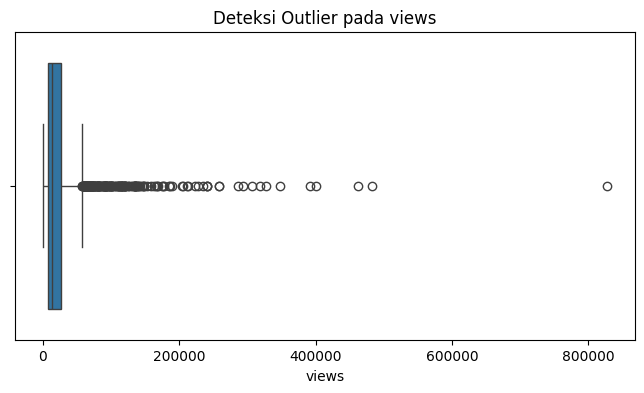

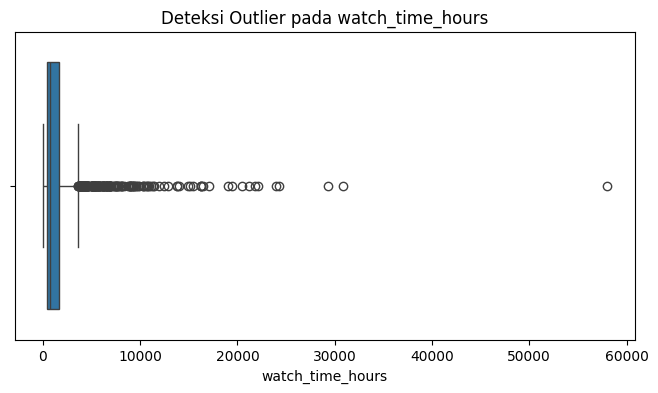

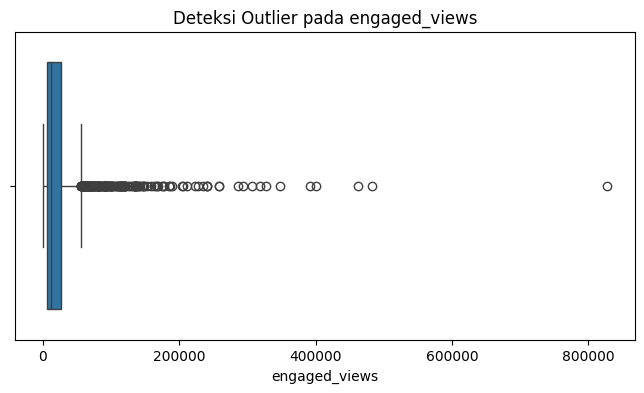

In [92]:
import seaborn as sns
import matplotlib.pyplot as plt

# List fitur utama yang akan dianalisis
features_to_check = ['views', 'watch_time_hours', 'engaged_views']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()

* Kesimpulan:
Data  tidak berdistribusi normal. Titik-titik kemungkinan besar adalah video-video "viral" yang performanya jauh melampaui rata-rata konten lainnya.

* Metrik pendapatan (revenue)

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

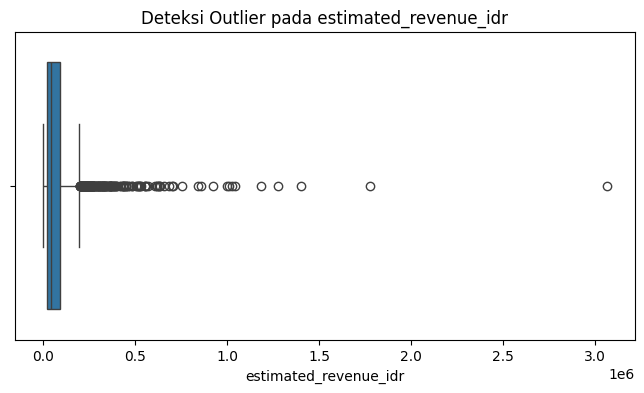

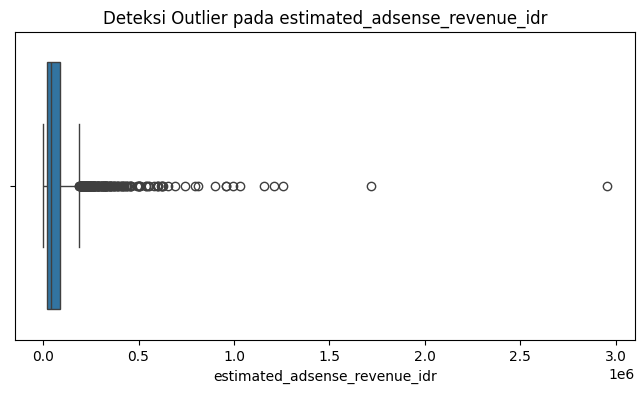

In [93]:

# List fitur utama yang akan dianalisis
features_to_check = ['estimated_revenue_idr', 'estimated_adsense_revenue_idr']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

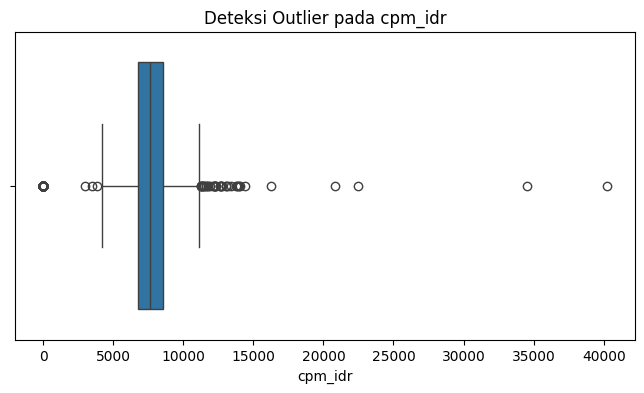

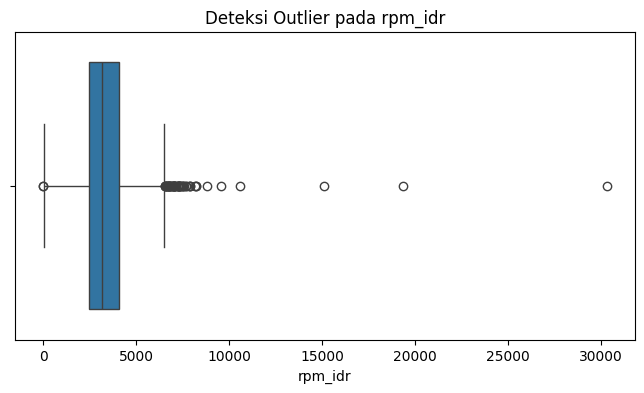

In [94]:


features_to_check = ['cpm_idr', 'rpm_idr']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()

* Retensi danEfisiensi

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

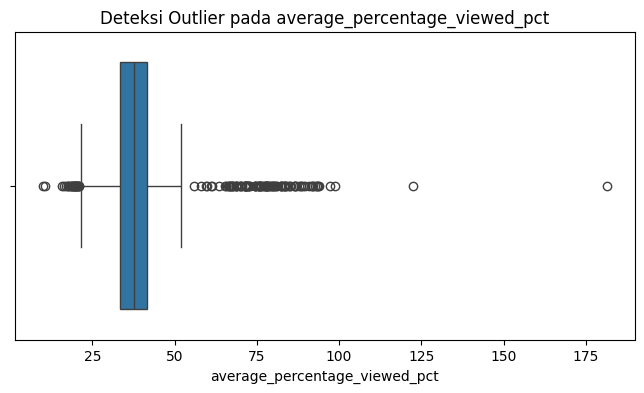

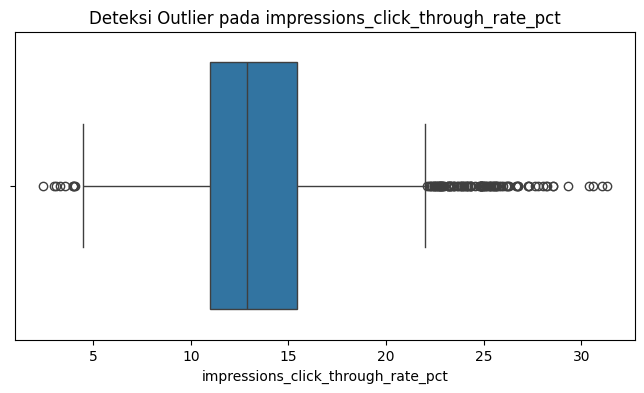

In [95]:
features_to_check = ['average_percentage_viewed_pct', 'impressions_click_through_rate_pct']

for feature in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f'Deteksi Outlier pada {feature}')
    plt.show()


Rangkuman dari hasil analisis grafik outlier pada notebook tersebut:

1. Outlier pada Metrik Performa (Views, Watch Time Hours, Engaged Views)

Grafik: Menunjukkan adanya banyak titik data yang berada jauh di atas batas atas (upper whisker) dari boxplot.
Kesimpulan: Distribusi data tidak normal dan memiliki rentang yang sangat lebar ke arah atas (right-skewed). Titik-titik pencilan (outlier) ini kemungkinan besar merepresentasikan video-video "viral" yang performa dan jumlah penontonnya jauh melampaui rata-rata konten video lainnya.

2. Outlier pada Metrik Pendapatan (Estimated Revenue IDR, Estimated AdSense Revenue IDR)

Grafik: Mirip dengan metrik performa, terdapat titik-titik ekstrem yang nilainya jauh lebih besar dari mayoritas data.
Kesimpulan: Ada beberapa video spesifik yang menghasilkan pendapatan yang secara signifikan jauh lebih tinggi dibandingkan dengan video lainnya.

3. Outlier pada Metrik Retensi dan Efisiensi (Average Percentage Viewed, Impressions Click-Through Rate / CTR)

Grafik: Walaupun boxplot menunjukkan data lebih banyak terpusat (terkonsentrasi) pada rentang nilai tertentu (karena berupa persentase), tetap ditemukan adanya nilai ekstrem.
Maka Nilai-nilai ekstrem ini mengindikasikan adanya pola retensi penonton yang spesifik atau rasio klik-tayang (CTR) yang sangat tinggi/sangat rendah pada beberapa video tertentu dibandingkan rata-rata umum.


* Dari hasil yang telah saya diskusikan dengan GEMINI AI, maka kesimpulan yang saya ambil saya akan menggunakan IQR sebagai flagging, artinya data yang video viral whic is diluar garis akan saya tandai sebagai is viral dan saya akan padukan dengan algoritma robust agar membuat prediksi semakin akurat.

* IQR Flagging

### 🚀 Feature Engineering Lanjutan: IQR Flagging ()
Karena kita tidak menghapus video viral, kita harus memberi 'tanda' agar algoritma Machine Learning tahu bahwa video ini spesial. 
Kita menggunakan batas statistik matematis **Interquartile Range (IQR)**. Jika *views* sebuah video melewati batas , maka video tersebut diberi bendera .

In [96]:
# 1. Tentukan kolom target yang ingin dianalisis (contoh: 'views' atau 'engaged_views')
kolom_target = 'views'
# 2. Hitung Q1 (Kuartil 1) dan Q3 (Kuartil 3)
Q1 = df[kolom_target].quantile(0.25)
Q3 = df[kolom_target].quantile(0.75)
# 3. Hitung rentang IQR
IQR = Q3 - Q1
# 4. Tentukan Batas Atas (Upper Bound)
# Formula standar untuk batas atas pencilan (outlier) adalah Q3 + (1.5 * IQR)
batas_atas = Q3 + 1.5 * IQR
print(f"Batas atas (Viral Threshold) untuk {kolom_target}: {batas_atas}")
# 5. Lakukan Flagging dengan membuat kolom baru (1 jika viral, 0 jika normal)
df['is_viral'] = np.where(df[kolom_target] > batas_atas, 1, 0)
# Cek sebaran video viral vs normal
print(df['is_viral'].value_counts())

Batas atas (Viral Threshold) untuk views: 57530.875
is_viral
0    1785
1     203
Name: count, dtype: int64


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   video_title                         1988 non-null   str           
 1   duration                            1988 non-null   float64       
 2   average_percentage_viewed_pct       1988 non-null   float64       
 3   engaged_views                       1988 non-null   float64       
 4   youtube_premium_idr                 1988 non-null   float64       
 5   watch_page_ads_idr                  1988 non-null   float64       
 6   estimated_adsense_revenue_idr       1988 non-null   float64       
 7   youtube_ad_revenue_idr              1988 non-null   float64       
 8   ad_impressions                      1988 non-null   float64       
 9   playback_based_cpm_idr              1988 non-null   float64       
 10  cpm_idr                            

### 📉 Normalisasi Data: Log Transformation (`np.log1p`)
Video viral memiliki rentang angka yang sangat jauh (jutaan) dibandingkan video normal (ribuan). Hal ini membuat algoritma (seperti Regresi) menjadi bias. 
Untuk menjinakkannya, kita menerapkan **Logaritma Natural (Log1p)**. Logika ini akan merapatkan skala angka ekstrem menjadi skala belasan, sehingga model bisa mempelajarinya dengan stabil tanpa kehilangan informasi esensial.

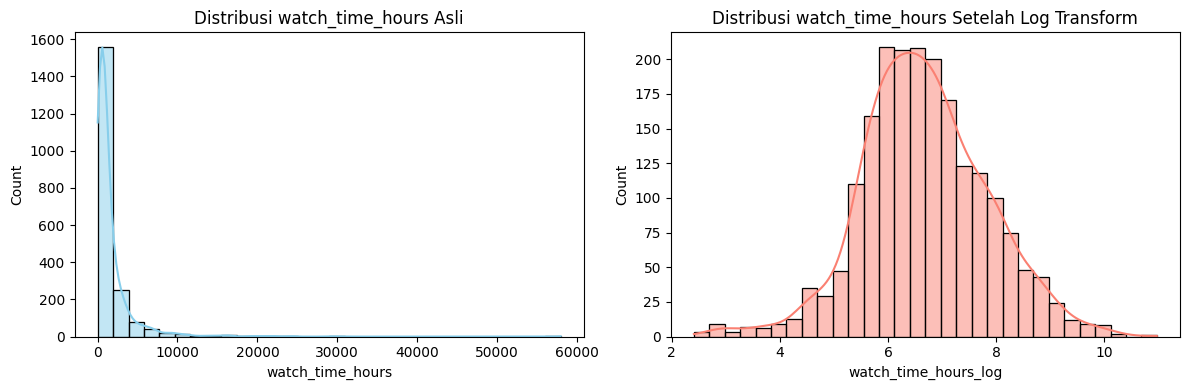

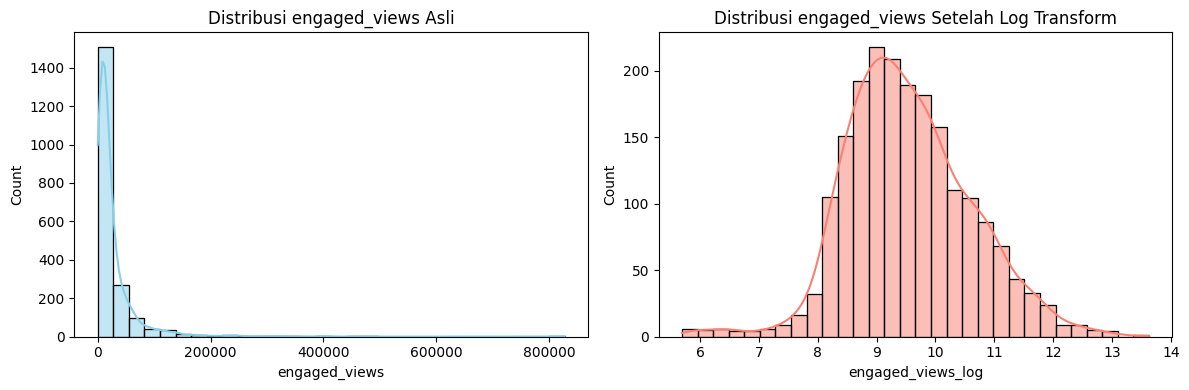

       watch_time_hours_log  engaged_views_log
count           1988.000000        1988.000000
mean               6.673678           9.539305
std                1.169527           1.064818
min                2.412945           5.693732
25%                5.918411           8.810049
50%                6.599597           9.432924
75%                7.420152          10.181659
max               10.967561          13.625685


In [98]:
# 1. Daftar kolom yang terdeteksi memiliki outlier ekstrem dari box plot sebelumnya
outlier_features = ['watch_time_hours', 'engaged_views']

# 2. Lakukan Transformasi Logaritmik (log1p)
for feature in outlier_features:
    df[f'{feature}_log'] = np.log1p(df[feature])

# 3. Visualisasi Perbandingan Sebelum vs Sesudah
for feature in outlier_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Sebelum (Data Asli - Skewed)
    sns.histplot(df[feature], bins=30, ax=axes[0], kde=True, color='skyblue')
    axes[0].set_title(f'Distribusi {feature} Asli')
    
    # Plot Sesudah (Data Log - Lebih Normal/Terpusat)
    sns.histplot(df[f'{feature}_log'], bins=30, ax=axes[1], kde=True, color='salmon')
    axes[1].set_title(f'Distribusi {feature} Setelah Log Transform')
    
    plt.tight_layout()
    plt.show()

# 4. Verifikasi perubahan distribusi secara numerik (Opsional)
# Ini membantu memastikan distribusi data menjadi lebih merata dan terpusat [cite: 155]
print(df[[f'{f}_log' for f in outlier_features]].describe())

## CATATAN
* Nanti di tahap modeling...
from sklearn.ensemble import RandomForestRegressor
*  Fitur yang digunakan (X) termasuk 'is_viral' untuk memberi konteks
X = df[['duration', 'average_percentage_viewed_pct', 'is_viral', ...]] 
* Target yang diprediksi (y) BISA menggunakan data yang sudah di-log
y = df['views_log'] 
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

### 📊 Analisis Outlier (Identifikasi Video Viral)
Boxplot di bawah ini digunakan untuk melihat sebaran data. Kita akan melihat banyak titik di luar batas atas (titik-titik *Outlier*). 

**Penting:** Dalam proyek ini, kita **TIDAK AKAN MENGHAPUS** titik-titik tersebut. Menghapus *outlier* di data YouTube sama dengan menghapus video-video tersukses kita dari memori model Machine Learning.

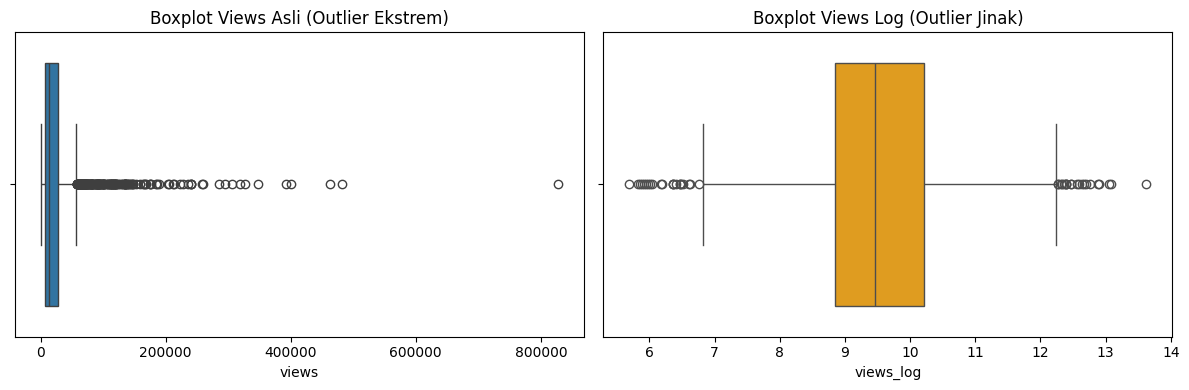

In [99]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Boxplot sebelum di-log (Outlier terlihat sangat jauh)
sns.boxplot(x=df['views'], ax=axes[0])
axes[0].set_title('Boxplot Views Asli (Outlier Ekstrem)')
# Boxplot sesudah di-log (Outlier sudah "dijinakkan")
sns.boxplot(x=df['views_log'], ax=axes[1], color='orange')
axes[1].set_title('Boxplot Views Log (Outlier Jinak)')
plt.tight_layout()
plt.show()

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   video_title                         1988 non-null   str           
 1   duration                            1988 non-null   float64       
 2   average_percentage_viewed_pct       1988 non-null   float64       
 3   engaged_views                       1988 non-null   float64       
 4   youtube_premium_idr                 1988 non-null   float64       
 5   watch_page_ads_idr                  1988 non-null   float64       
 6   estimated_adsense_revenue_idr       1988 non-null   float64       
 7   youtube_ad_revenue_idr              1988 non-null   float64       
 8   ad_impressions                      1988 non-null   float64       
 9   playback_based_cpm_idr              1988 non-null   float64       
 10  cpm_idr                            

In [101]:
df.head()
df.isnull().sum()

video_title                           0
duration                              0
average_percentage_viewed_pct         0
engaged_views                         0
youtube_premium_idr                   0
watch_page_ads_idr                    0
estimated_adsense_revenue_idr         0
youtube_ad_revenue_idr                0
ad_impressions                        0
playback_based_cpm_idr                0
cpm_idr                               0
estimated_monetized_playbacks         0
rpm_idr                               0
views                                 0
watch_time_hours                      0
subscribers                           0
estimated_revenue_idr                 0
impressions                           0
impressions_click_through_rate_pct    0
video_id                              0
ts1_views                             0
ts2_views                             0
ts3_views                             0
ts4_views                             0
publish_time_wib                      0


### 💾 Export Master Data
Data telah berhasil dibersihkan, di-*flag*, dan di-*log*. Dataset ini sekarang adalah **'Master Data'** yang secara matematis sangat aman dan siap digunakan oleh tim untuk tahap *Feature Engineering* selanjutnya.

In [102]:
# Mundur dua folder dari notebooks/versi_wildan/ ke folder utama, lalu masuk ke folder data
path_simpan = '../../data/Data_Cleaned_Wildan.csv'
df.to_csv(path_simpan, index=False)
print(f"Data berhasil diekspor dan disimpan di: {path_simpan}")
print(f"Total baris dan kolom final: {df.shape}")


Data berhasil diekspor dan disimpan di: ../../data/Data_Cleaned_Wildan.csv
Total baris dan kolom final: (1988, 35)


### 🚀 Feature Engineering Lanjutan: IQR Flagging ()
Karena kita tidak menghapus video viral, kita harus memberi 'tanda' agar algoritma Machine Learning tahu bahwa video ini spesial. 
Kita menggunakan batas statistik matematis **Interquartile Range (IQR)**. Jika *views* sebuah video melewati batas , maka video tersebut diberi bendera .

### 📉 Normalisasi Data: Log Transformation (`np.log1p`)
Video viral memiliki rentang angka yang sangat jauh (jutaan) dibandingkan video normal (ribuan). Hal ini membuat algoritma (seperti Regresi) menjadi bias. 
Untuk menjinakkannya, kita menerapkan **Logaritma Natural (Log1p)**. Logika ini akan merapatkan skala angka ekstrem menjadi skala belasan, sehingga model bisa mempelajarinya dengan stabil tanpa kehilangan informasi esensial.

Berikut adalah rangkuman dari semua hal krusial yang telah Anda selesaikan di data_prep_wildan.ipynb. Anda bisa menyalin teks ini ke dalam sel Markdown di akhir notebook sebagai dokumentasi proyek Anda:

Tahap 1: Pengumpulan & Standardisasi Data
Loading Data: Membaca dataset mentah hasil gabungan (Data_Merged_Fix.csv).
Pembersihan Nama Kolom: Menyeragamkan semua nama kolom menjadi format snake_case (huruf kecil semua dan spasi diganti underscore) agar mudah dipanggil dalam kode Python.
Tahap 2: Pembersihan Data (Data Cleaning)
Menghapus Kolom Tidak Penting: Membuang kolom-kolom yang redundan atau tidak relevan dengan tujuan model (seperti content dan beberapa indikator revenue yang tidak terpakai).
Menangani Missing Values:
Menghapus kolom yang memiliki lebih dari 95% data kosong (NaN).
Mengisi (impute) nilai kosong pada kolom Time Series (seperti ts1_views, ts2_views, dll) dengan angka 0.
Tahap 3: Transformasi Tipe Data
Konversi Waktu: Mengubah format average_view_duration yang awalnya berformat "JJ:MM:DD" menjadi total detik numerik (average_view_duration_sec).
Konversi Tanggal: Memastikan kolom publish_date_wib terbaca dengan benar sebagai format datetime.
Tahap 4: Analisis Outlier (Exploratory Data Analysis)
Melakukan analisis visual menggunakan Boxplot pada metrik-metrik kunci (views, watch_time_hours, revenue, CTR, dll).
Temuan Utama: Ditemukan bahwa data memiliki distribusi right-skewed (miring ke kanan) dengan banyaknya outlier ekstrem di sisi atas. Outlier ini tidak dihapus karena merepresentasikan real-case dari video-video "viral".
Tahap 5: Penanganan Outlier (Feature Engineering & Robust Transformation)
IQR Flagging: Menerapkan metode Interquartile Range (IQR) bukan untuk menghapus data, melainkan untuk membuat fitur baru bernama is_viral (1 = viral, 0 = normal). Ini memberikan "konteks" khusus bagi Machine Learning.
Log Transformation: Menerapkan np.log1p pada kolom metrik yang ekstrem (seperti views_log, watch_time_hours_log, engaged_views_log) untuk menormalkan distribusi data secara matematis agar algoritma model tidak bias atau error.
Status Saat Ini: Dataset telah bersih, memiliki fitur tambahan yang sangat representatif untuk kondisi dunia nyata (real-case), dan sudah berhasil diekspor. Data kini 100% siap untuk digunakan pada tahap Feature Engineering (Lanjutan) atau langsung masuk ke Model Training!